## Project 2: Noncommunicable diseases & risk factors vs Deaths

**Name:** Mariah Ridley

What i’m proposing to do is to compare the non-communicable diseases and risk factors vs the
global mortality data. With the deaths dataset, I could look at premature mortality or deaths for
certain age groups across different regions. Using the NCD dataset, I can add the risk factors
like tobacco use, physical inactivity, and etc. Then I can merge the data by the year and the
country to see the different risk-factors across different countries and how the morality changes.

This is the non-communicable diseases dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ncd = pd.read_excel('ncd.xlsx', engine='openpyxl')

# creating a year column for merging later then dropping 'date'
ncd['year'] = pd.to_numeric(ncd['date'], errors='coerce')

#dropping unnecessary columns 
ncd = ncd.drop(columns=['setting','date', 'update', 'dataset_id', 'flag','source','dimension','population','se',
                        'ordered_dimension','subgroup_order','reference_subgroup'])
ncd = ncd.rename(
    columns= {
        'subgroup': 'sex',
        'whoreg6': 'region',
        'wbincome2024': 'income level (2024)'
    }
)
ncd.head()

,indicator_abbr,indicator_name,sex,estimate,ci_lb,ci_ub,setting_average,iso3,favourable_indicator,indicator_scale,region,income level (2024),year
0,NCD_GLUC_03,Raised fasting blood glucose (>=7.0 mmol/L) (1...,Female,3.7,1.2,8.2,3.3,AFG,0,100,Eastern Mediterranean,Low income,1980
1,NCD_GLUC_03,Raised fasting blood glucose (>=7.0 mmol/L) (1...,Male,2.8,0.9,6.4,3.3,AFG,0,100,Eastern Mediterranean,Low income,1980
2,NCD_GLUC_04,Raised fasting blood glucose (>=7.0 mmol/L) (1...,Female,5.4,2.0,11.3,4.9,AFG,0,100,Eastern Mediterranean,Low income,1980
3,NCD_GLUC_04,Raised fasting blood glucose (>=7.0 mmol/L) (1...,Male,4.5,1.5,9.5,4.9,AFG,0,100,Eastern Mediterranean,Low income,1980
4,NCD_GLUC_03,Raised fasting blood glucose (>=7.0 mmol/L) (1...,Female,3.8,1.3,8.1,3.3,AFG,0,100,Eastern Mediterranean,Low income,1981


This is the mortality rate dataset.

In [2]:
deaths_raw = pd.read_excel('death_age.xlsx',engine='openpyxl')

#dropping columns we don't need or have NAN
deaths = deaths_raw.drop(columns=[
    'setting',
    'indicator_abbr',
    'indicator_name',
    'dimension',
    'population',
    'setting_average',
    'favourable_indicator',
    'indicator_scale',
    'ordered_dimension',
    'subgroup_order',
    'reference_subgroup',
    'update',
    'dataset_id',
    'flag',
    'source',
    'se'])
# renaming columns for simplicity
deaths = deaths.rename(columns={
    'whoreg6': 'region',
    'wbincome2024': 'income level (2024)',
    'subgroup': 'age',
    'date': 'year'
})
deaths.head()

,year,age,estimate,ci_lb,ci_ub,iso3,region,income level (2024)
0,2021,1-4 years,18181.007812,14755.407227,22622.164062,AFG,Eastern Mediterranean,Low income
1,2021,10-14 years,4081.999756,3746.405273,4411.497070,AFG,Eastern Mediterranean,Low income
2,2021,15-19 years,26234.806641,24550.261719,28073.144531,AFG,Eastern Mediterranean,Low income
3,2021,20-24 years,21868.806641,20235.388672,23629.302734,AFG,Eastern Mediterranean,Low income
4,2021,25-29 years,13076.522461,11521.080078,15278.729492,AFG,Eastern Mediterranean,Low income


## Cleaning: ##

In [3]:
#cleaning the strings
ncd['year'] = pd.to_numeric(ncd['year'], errors='coerce')
for col in ['estimate', 'ci_lb', 'ci_ub', 'setting_average']:
    if col in ncd.columns:
        ncd[col] = pd.to_numeric(ncd[col], errors='coerce')

# stripping the whitespace and standardizing it
for col in ['iso3', 'sex', 'region', 'income level (2024)']:
    if col in ncd.columns:
        ncd[col] = ncd[col].astype(str).str.strip()

# removes rows where the iso3, which is the country code, is missing, or the year is missing
ncd = ncd.dropna(subset=['iso3', 'year']) 

# i need to combine the setting, sex, whoreg6 and income
ncd_grouped = (
    ncd.groupby([
        "iso3",
        "indicator_abbr",
        "sex",
        "region",
        "income level (2024)",
        "year"
    ])
    .agg({
        "estimate": "mean",
        "ci_lb": "mean",
        "ci_ub": "mean",
        "setting_average": "mean"
    })
    .reset_index()
)
 # pivoting the table so that the columns are the risk factors
wide = ncd_grouped.pivot_table(
    index=["iso3", "sex", "region", "income level (2024)","year"],
    columns="indicator_abbr",
    values="estimate",
    aggfunc="mean"
).reset_index()

wide.columns = [str(c) for c in wide.columns]

In [4]:
# filling the nan columns with the mean, i could get rid of this code because its all 
num_cols_wide = wide.select_dtypes(include=['number']).columns

wide[num_cols_wide] = wide[num_cols_wide].fillna(wide[num_cols_wide].median())
wide.head()

,iso3,sex,region,income level (2024),year,Adult_curr_cig_smoking,Adult_curr_e_cig,Adult_curr_smokeless,Adult_curr_tob_smoking,Adult_curr_tob_use,...,SA_0000001807,SA_0000001819,SA_0000001820,Yth_curr_cig_smoking,Yth_curr_e_cig,Yth_curr_smokeless,Yth_curr_tob_smoking,Yth_curr_tob_use,Yth_daily_cig_smoking,Yth_daily_tob_smoking
0,AFG,Female,Eastern Mediterranean,Low income,1980,11.4,1.5,1.35,14.9,12.4,...,99.87758,9.45,40.05,6.85,8.8,3.25,9.4,12.4,1.0,2.95
1,AFG,Female,Eastern Mediterranean,Low income,1981,11.4,1.5,1.35,14.9,12.4,...,99.87758,9.45,40.05,6.85,8.8,3.25,9.4,12.4,1.0,2.95
2,AFG,Female,Eastern Mediterranean,Low income,1982,11.4,1.5,1.35,14.9,12.4,...,99.87758,9.45,40.05,6.85,8.8,3.25,9.4,12.4,1.0,2.95
3,AFG,Female,Eastern Mediterranean,Low income,1983,11.4,1.5,1.35,14.9,12.4,...,99.87758,9.45,40.05,6.85,8.8,3.25,9.4,12.4,1.0,2.95
4,AFG,Female,Eastern Mediterranean,Low income,1984,11.4,1.5,1.35,14.9,12.4,...,99.87758,9.45,40.05,6.85,8.8,3.25,9.4,12.4,1.0,2.95


So my datasets share iso3, region, year, and income level (2024). But I need to standardize the columns and merging the datasets to combine.

In [5]:
# convert year
deaths['year'] = pd.to_numeric(deaths['year'], errors='coerce')
#putting the ages in order
age_order = [
    '<1 year',
    '1-4 years',
    '5-9 years',
    '10-14 years',
    '15-19 years',
    '20-24 years',
    '25-29 years',
    '30-34 years',
    '35-39 years',
    '40-44 years',
    '45-49 years',
    '50-54 years',
    '55-59 years',
    '60-64 years',
    '65-69 years',
    '70-74 years',
    '75-79 years',
    '80-84 years',
    '85+ years'
]

if 'age' in deaths.columns:
    valid_levels = [a for a in age_order if a in deaths['age'].unique()]
    if valid_levels:
        deaths['age'] = pd.Categorical(deaths['age'], categories=valid_levels, ordered=True)

# drop rows that are missing things and rename deaths estimate to the date rate bc thats what were calculating 
deaths_clean = deaths.dropna(subset=['iso3', 'year'])
deaths_clean = deaths_clean.rename(columns={'estimate': 'death_rate'})

combined = pd.merge(
    wide,
    deaths_clean,
    on=["iso3", "region", "income level (2024)", "year"],
    how="inner"
)
combined

,iso3,sex,region,income level (2024),year,Adult_curr_cig_smoking,Adult_curr_e_cig,Adult_curr_smokeless,Adult_curr_tob_smoking,Adult_curr_tob_use,...,Yth_curr_e_cig,Yth_curr_smokeless,Yth_curr_tob_smoking,Yth_curr_tob_use,Yth_daily_cig_smoking,Yth_daily_tob_smoking,age,death_rate,ci_lb,ci_ub
0,AFG,Female,Eastern Mediterranean,Low income,2021,11.4,1.5,1.35,14.9,12.4,...,8.8,3.25,9.4,12.4,1.0,2.95,1-4 years,18181.007812,14755.407227,22622.164062
1,AFG,Female,Eastern Mediterranean,Low income,2021,11.4,1.5,1.35,14.9,12.4,...,8.8,3.25,9.4,12.4,1.0,2.95,10-14 years,4081.999756,3746.405273,4411.497070
2,AFG,Female,Eastern Mediterranean,Low income,2021,11.4,1.5,1.35,14.9,12.4,...,8.8,3.25,9.4,12.4,1.0,2.95,15-19 years,26234.806641,24550.261719,28073.144531
3,AFG,Female,Eastern Mediterranean,Low income,2021,11.4,1.5,1.35,14.9,12.4,...,8.8,3.25,9.4,12.4,1.0,2.95,20-24 years,21868.806641,20235.388672,23629.302734
4,AFG,Female,Eastern Mediterranean,Low income,2021,11.4,1.5,1.35,14.9,12.4,...,8.8,3.25,9.4,12.4,1.0,2.95,25-29 years,13076.522461,11521.080078,15278.729492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196987,ZWE,Male,African,Lower middle income,2021,11.4,1.5,1.35,14.9,12.4,...,8.8,3.25,9.4,12.4,1.0,2.95,70-74 years,169.662521,65.172134,401.269104
196988,ZWE,Male,African,Lower middle income,2021,11.4,1.5,1.35,14.9,12.4,...,8.8,3.25,9.4,12.4,1.0,2.95,75-79 years,206.956161,82.235008,501.451935
196989,ZWE,Male,African,Lower middle income,2021,11.4,1.5,1.35,14.9,12.4,...,8.8,3.25,9.4,12.4,1.0,2.95,80-84 years,236.831894,84.304932,585.494019
196990,ZWE,Male,African,Lower middle income,2021,11.4,1.5,1.35,14.9,12.4,...,8.8,3.25,9.4,12.4,1.0,2.95,85+ years,449.633209,125.950027,1182.045166


After cleaning the NCD dataset and pivoting it, many of the risk-factor indicator columns have the same values across years. This is because of the original WHO NCD data. First, the raw NCD dataset does not provide a full year-by-year time series for each indicator. Many indicators like adult smoking, obesity rates, or blood pressure are only measured periodically so most years have missing values originally. Theres alot of NaN values.

During cleaning, I created a wide table where each NCD indicator became its own column. Because many country-year rows were missing values for certain indicators, those missing values needed to be filled for visualizations later. So, I filled missing numeric values with each column’s median, which could be a bad idea. I don't know if that was the correct approach. But it allowed me to merge the datasets and fills the missing data which was what most of the dataset contained.

## Visualizations: ##

Here's the key variables that I would use to compare.

In [6]:
key_vars = [
    'death_rate',
    'Adult_curr_cig_smoking',
    'Adult_curr_tob_use',
    'NCD_BMI_25A',
    'NCD_BMI_30A',
    'NCD_GLUC_04',
    'NCD_PAA',  
    'NCD_PAC'        
]
combined[key_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
death_rate,196976.0,2036.611032,2.809450e+04,0.00000,0.129053,11.901820,190.633423,3.068517e+06
Adult_curr_cig_smoking,196992.0,12.152083,5.312861e+00,1.20000,11.400000,11.400000,11.400000,6.450000e+01
Adult_curr_tob_use,196992.0,13.009635,5.019515e+00,2.10000,12.400000,12.400000,12.400000,6.550000e+01
NCD_BMI_25A,196992.0,50.940938,1.875990e+01,6.51131,36.939010,54.289940,66.029110,9.377407e+01
NCD_BMI_30A,196992.0,22.545289,1.381280e+01,0.97907,12.197820,21.094280,30.399397,7.940410e+01
NCD_GLUC_04,196992.0,6.400000,2.004624e-12,6.40000,6.400000,6.400000,6.400000,6.400000e+00
NCD_PAA,196992.0,27.144140,1.350253e+01,2.54377,17.358083,24.278185,35.540793,7.290891e+01
NCD_PAC,196992.0,27.261602,1.396216e+01,1.83388,16.790547,24.776110,36.440350,7.282803e+01


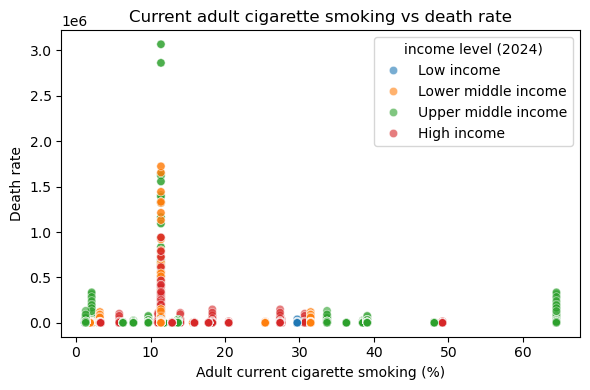

In [7]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=combined,
    x='Adult_curr_cig_smoking',
    y='death_rate',
    hue='income level (2024)',
    alpha=0.6
)
plt.title("Current adult cigarette smoking vs death rate")
plt.xlabel("Adult current cigarette smoking (%)")
plt.ylabel("Death rate")
plt.tight_layout()
plt.show()

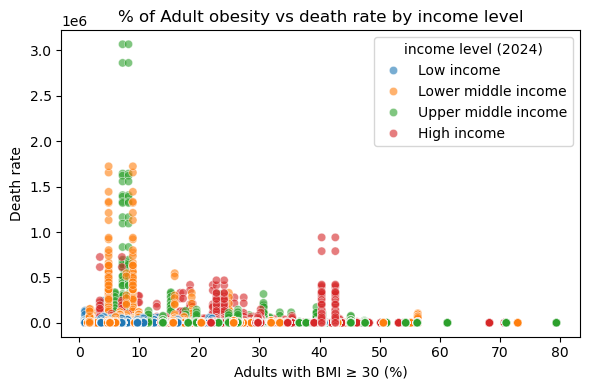

In [8]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=combined,
    x='NCD_BMI_30A',
    y='death_rate',
    hue='income level (2024)',
    alpha=0.6
)
plt.title("% of Adult obesity vs death rate by income level")
plt.xlabel("Adults with BMI ≥ 30 (%)")
plt.ylabel("Death rate")
plt.tight_layout()
plt.show()

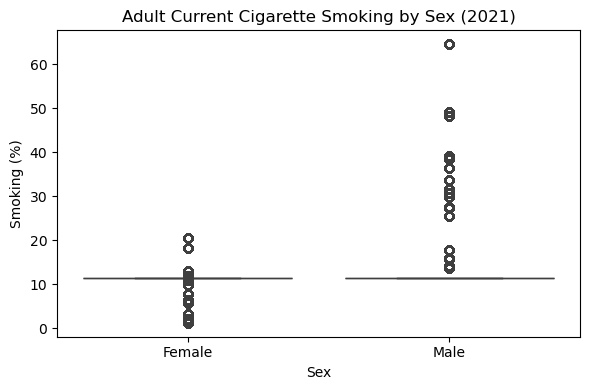

In [9]:
subset = combined[combined['year'] == 2021]

plt.figure(figsize=(6, 4))
sns.boxplot(data=subset, x='sex', y='Adult_curr_cig_smoking')

plt.title("Adult Current Cigarette Smoking by Sex (2021)")
plt.xlabel("Sex")
plt.ylabel("Smoking (%)")
plt.tight_layout()
plt.show()

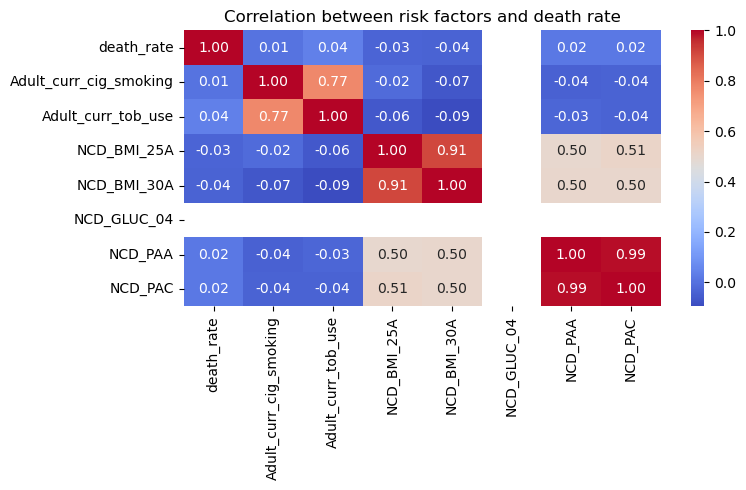

In [10]:
plt.figure(figsize=(8,5))
sns.heatmap(combined[key_vars].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation between risk factors and death rate")
plt.tight_layout()
plt.show()

So these results aren't good. I feel like I should probably save the explanation for part 3 but the death rate has almost no linear correlation with smoking, BMI, glucose, or physical activity. Since many of the risk-factor values were missing and filled with medians it makes sense. However, the risk factors correlate with each other. I think because I included the age and sex it threw off the correlation between the two. I know there's a correlation I just need to figure out how to prove it.

## Inference

Here are my hypotheses about my data:
- H0 = There is no relationship between NCD risk factors (like tobacco use, high BMI, low physical activity, etc.) and noncommunicable-disease death rates across countries and years.
- H1 =  Countries with worse NCD risk-factor profiles have higher noncommunicable-disease death rates.

For the alternative hypothesis, I want at least one risk-factor coefficient that differs from zero, and I expect them to be positive.

I fit a linear regression of death_rate on Adult_curr_tob_use, NCD_BMI_30A, and NCD_PAA to test whether higher tobacco use, obesity, and low physical activity are associated with higher mortality.

In [11]:
import statsmodels.formula.api as smf

# pick adults at age 25-29
adult =combined[combined["age"] == "25-29 years"]   # example

# fit linear regression of death_rate vs key risk factors
model = smf.ols("death_rate ~ Adult_curr_tob_use + NCD_BMI_30A + NCD_PAA",data=adult).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             death_rate   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     66.19
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           2.18e-42
Time:                        20:20:49   Log-Likelihood:                -99423.
No. Observations:               10368   AIC:                         1.989e+05
Df Residuals:                   10364   BIC:                         1.989e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           -387.7518    125

In [12]:
# split by median tobacco use
median_tob = adult["Adult_curr_tob_use"].median()
high_tob = adult[adult["Adult_curr_tob_use"] > median_tob]["death_rate"]
low_tob  = adult[adult["Adult_curr_tob_use"] <= median_tob]["death_rate"]

high_tob.mean(), low_tob.mean()

(2529.642095538566, 383.7220721393514)

In [13]:
# 95% confidence intervals for coefficients
model.conf_int()

,0,1
Intercept,-633.232524,-142.270986
Adult_curr_tob_use,44.865641,72.117430
NCD_BMI_30A,-33.661356,-22.220731
NCD_PAA,20.443550,32.098730


- The coefficient for Adult_curr_tob_use is about 58.5, with a 95% CI of roughly [44.9, 72.1] and p-value < 0.001, so higher adult tobacco use is significantly associated with higher death rates.

- NCD_BMI_30A has a negative coefficient around −27.9 and a CI (−33.7, −22.2). This means in this dataset higher prevalence of BMI ≥ 30 is associated with lower death rates. This is significant but opposite of our hypothesis that more obesity leads to more deaths. This suggest a confoudning factor that maybe richer countries have more obesity but better health systems.

- NCD_PAA (physical activity) is positive and about 26.3, CI (20.4, 32.1). So higher levels of this are associated with higher death rates. However, this could reflect something else. It could reflect how the indicator is correlated to country-level factors rather than a causal effect.

Since all three coefficients have very small p‑values and 95% confidence intervals that do not include 0, there is strong statistical evidence that they are associated with death rates according to this data.

I think this data has a lot of limitations. The WHO numbers for deaths and risk factors are estimates, and they’re probably less accurate for low‑income countries, so the data itself could be biased. OLS assumes a linear relationship, homoscedastic  errors, and approximately normal residuals, but the stats show the residuals are super skewed, so that assumption is not met. On top of that, I didn’t control for things like healthcare quality or age structure, so the coefficients probably mix up the effects of many different factors and should not be taken as causal. In all the data does suggests that high tobacco use kinda occurs with high death rates, but it does not prove that increasing tobacco use would change the death rate by the estimated amount (58.49).

## Final Step: Prediction Modeling ##

My target variable to model is the death_rate (y) of a specific age range. My specific age group is 25-29 years. The variables I'll use for predicting are: 
    
    - Adult_curr_cig_smoking (current adult cigarette smoking)
    - Adult_curr_tob_use (any current adult tobacco use)
    - NCD_BMI_25A (prevalence of BMI ≥ 25, adults)
    - NCD_BMI_30A (prevalence of BMI ≥ 30, adults)
    - NCD_PAA (physical activity, adults)
    - NCD_PAC (physical activity, children)

I want to prove how smoking, obesity, and physical inactivity affect the mortality rate across countries and years. My two linear approaches are linear regression and random forest. 

In [14]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


# first we filter ages 25-29 and drop any rows with missing values
cols = [
    'death_rate',
    'Adult_curr_cig_smoking',
    'Adult_curr_tob_use',
    'NCD_BMI_25A',
    'NCD_BMI_30A',
    'NCD_PAA',
    'NCD_PAC',
    'age'
]

df_model = combined[cols].copy()
df_model = df_model[df_model['age'] == '25-29 years'].dropna()

# now we choose an x and y value to perform the test on
factor_cols= [
    'Adult_curr_cig_smoking',
    'Adult_curr_tob_use',
    'NCD_BMI_25A',
    'NCD_BMI_30A',
    'NCD_PAA',
    'NCD_PAC'
]
x = df_model[factor_cols]
y = df_model['death_rate']

# train test split
x_train_val, x_test, y_train_val, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
# 0.25 * 0.8 = 0.2 ?
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.25, random_state=42)


In [15]:
# linear regression
lin = LinearRegression()
lin.fit(x_train, y_train)

y_pred = lin.predict(x_val)
y_test_pred = lin.predict(x_test)

mse_line = mean_squared_error(y_val,y_pred)
rmse_line = np.sqrt(mse_line)
r2_line = r2_score(y_val, y_pred)

mse_test_lin = mean_squared_error(y_test,y_test_pred)
rmse_test_lin = np.sqrt(mse_test_lin)
r2_test_lin = r2_score(y_test, y_test_pred)

print("Validation RMSE:", rmse_line)
print("R^2:", r2_line)
print("Test RMSE:", rmse_test_lin)
print("Test R^2:", r2_test_lin)

Validation RMSE: 4633.585479564703
R^2: -0.005833024647648566
Test RMSE: 2278.365070773903
Test R^2: 0.028333877968050647


In [16]:
# random forest regression
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs = -1
)
rf.fit(x_train, y_train)

y_val_pred_rf = rf.predict(x_val)
y_test_pred_rf = rf.predict(x_test)

mse_val_rf = mean_squared_error(y_val, y_val_pred_rf)
rmse_val_rf = np.sqrt(mse_val_rf)
r2_val_rf = r2_score(y_val, y_val_pred_rf)

mse_test_rf = mean_squared_error(y_test, y_test_pred_rf)
rmse_test_rf = np.sqrt(mse_test_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)

print("Validation RMSE:", rmse_val_rf)
print("Validation R^2:", r2_val_rf)
print("Test RMSE:", rmse_test_rf)
print("Test R^2:", r2_test_rf)

Validation RMSE: 4305.675074963619
Validation R^2: 0.13149156986393817
Test RMSE: 2210.0727272873073
Test R^2: 0.08571085458876893


Because the target variable death_rate is continuous, the loss function is mean squared error and root mean squared error. Which measures the typical prediction error in the same units as death_rate.
The random forest is a better choice than the linear regression. Its validation RMSE is about 4306 and validation R^2 is about 0.13 vs 0 for the linear model. So random forest would be my model choice.

On the test set, the linear regression has RMSE ≈ 2278 and R^2 ≈ 0.03, meaning it is barely better than predicting a constant average death_rate and theres almost no variation. The random forest improves test RMSE to ≈ 2210 and test R^2 ≈ 0.086. Which indicates some nonlinear structure between NCD risk factors and death rates but still theres a lot of variability. The model could be useful for ranking country–year–age by predicted mortality given their smoking, obesity, and physical activity or finding which combination of risk factors are associated with higher or lower death rates among this age range. However, because R^2 is low and RMSE is large, the model is not very reliable.

I think mortality is strongly influenced by many unobserved factors and the death_rate is extremely skewed with heavy tails, which makes the target hard to model using only the available NCD risk factors.